# Dataset features

## Kraken2 analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from seaborn import objects as so
import tqdm
import taxoniq
from scipy.stats import f_oneway
from scipy.stats import kruskal
import json

plt.rcParams['svg.fonttype'] = 'none'

habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

In [12]:
with open('../results/2025-05-05.fastp-kraken2/.input') as f:
    index = list(map(lambda x: x.strip(), f.readlines()))

In [16]:
hits = []
counts = []
for file in tqdm.tqdm(index):
    hits_tmp = pd.read_csv(f'../results/2025-05-05.fastp-kraken2/{file}.classification.csv', index_col=0)
    hits.append(hits_tmp)
    
hits = pd.concat(hits).reset_index()
hits['library'] = hits['library'].apply(lambda x: "PV{:03d}".format(int(x.replace("PV", ""))))
hits

100%|██████████| 286/286 [00:00<00:00, 309.50it/s]


,library,classification-ratio,taxonid,scientific_name,count
0,PV051,0.858891,34305,Lotus japonicus,4028538
1,PV051,0.858891,1437201,Pentapetalae,1211253
2,PV051,0.858891,1437183,Mesangiospermae,984905
3,PV051,0.858891,2231393,50 kb inversion clade,173828
4,PV051,0.858891,91835,fabids,147742
...,...,...,...,...,...
600835,PV099,0.461511,2583851,Elizabethkingia sp. JS20170427COW,1
600836,PV099,0.461511,2583822,Plantibacter sp. M259,1
600837,PV099,0.461511,870501,Malaciobacter molluscorum LMG 25693,1
600838,PV099,0.461511,2580515,Agrobacterium sp. T29,1


In [17]:
def get_last_lineage(taxon):
    try:
        return taxon.ranked_lineage[0].tax_id
    except IndexError:
        return 0
    
def obtain_level(taxon, level):
    lineage = taxon.ranked_lineage
    try:
        u = list(filter(lambda x: x.rank.name == level, lineage))[0].scientific_name
    except IndexError:
        return pd.NA 
    return u

def obtain_rank(taxon):
    return taxon.rank.name
    
def fault_tolerant_taxoniq(x):
    try:
        return taxoniq.Taxon(x)
    except KeyError:
        return pd.NA
    

In [18]:
taxa = hits.value_counts(['taxonid', 'scientific_name']).reset_index()[['taxonid', 'scientific_name']]
taxa['taxon'] = taxa['taxonid'].apply(fault_tolerant_taxoniq)
taxa = taxa.dropna(subset=['taxon']).copy()
taxa['ltaxonid'] = taxa['taxon'].apply(get_last_lineage)
taxa = taxa.query('ltaxonid != 0').copy()
taxa['taxon'] = taxa['ltaxonid'].apply(lambda x: taxoniq.Taxon(x))
taxa['species'] = taxa['taxon'].apply(obtain_level, level='species')
taxa['genus'] = taxa['taxon'].apply(obtain_level, level='genus')
taxa['family'] = taxa['taxon'].apply(obtain_level, level='family')
taxa['order'] = taxa['taxon'].apply(obtain_level, level='order')
taxa['class'] = taxa['taxon'].apply(obtain_level, level='class')
taxa['phylum'] = taxa['taxon'].apply(obtain_level, level='phylum')
taxa['kingdom'] = taxa['taxon'].apply(obtain_level, level='kingdom')
taxa['superkingdom'] = taxa['taxon'].apply(obtain_level, level='superkingdom')
taxa['rank'] = taxa['taxon'].apply(obtain_rank)

In [19]:
hits = pd.merge(hits.rename(columns={'ltaxonid':'taxonid'}), taxa.drop_duplicates('ltaxonid').drop(columns='taxonid').rename(columns={'ltaxonid':'taxonid'}), on='taxonid')

In [20]:
mc24_table1 = pd.read_csv('data/mcleish24-TableS1.csv', sep=';')
mc24_table2 = pd.read_csv('data/mcleish24-TableS2.csv', sep=';')
mc24_table2 = mc24_table2.dropna(subset=['Library_code'])
mc24_table2['Collection_code'] = mc24_table2['Collection_code'].apply(lambda x: x.split("_")[0])
sample_reference = pd.merge(mc24_table1, mc24_table2, on='Collection_code').groupby(['Site_code', 'Collection_code', 'Library_code', 'Location', 'Host_taxon', 'Habitat', 'No_extracts'], as_index=False)['Date'].apply(lambda x: len(list(x)))
sample_reference

FileNotFoundError: [Errno 2] No such file or directory: '../../data/mcleish2024/nph20054-sup-0002-TablesS1.csv'

In [ ]:
hits = pd.merge(hits, sample_reference, left_on='library', right_on='Library_code')

/tmp/ipykernel_1761483/3074564053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


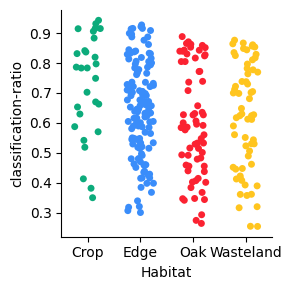

In [ ]:
hits_classratio = hits[['library', 'classification-ratio', 'Habitat']].groupby(['Habitat', 'library'], as_index=False).mean().copy()
g = sns.catplot(
    hits_classratio, x='Habitat', y='classification-ratio',  height=3.0,
    palette=habitat_palette, jitter=0.25
)

In [ ]:
f_oneway(
    hits_classratio.query('Habitat == "Crop"')['classification-ratio'],
    hits_classratio.query('Habitat == "Edge"')['classification-ratio'],
    hits_classratio.query('Habitat == "Oak"')['classification-ratio'],
    hits_classratio.query('Habitat == "Wasteland"')['classification-ratio'],
)

NameError: name 'hits_classratio' is not defined

In [ ]:
g = sns.catplot(
    x='superkingdom', y='count', data=hits.groupby('superkingdom')['count'].sum().reset_index().sort_values(by='superkingdom'), 
    kind='bar', height=3.0, color='navajowhite', edgecolor='black'
)
g.set_ylabels("# total reads")
g.ax.set_yscale('log')
g.set_xticklabels(rotation=45)

NameError: name 'hits' is not defined

In [ ]:
hits['is_possibly_host'] = hits['kingdom'] == 'Viridiplantae'

NameError: name 'hits' is not defined

In [ ]:
host_fraction = hits.groupby(['library', 'Site_code', 'Habitat']).apply(
    lambda x: x[x['is_possibly_host'] == 1]['count'].sum() / x['count'].sum()
).reset_index().rename(columns={0: 'host_fraction'})
host_fraction['other_fraction'] = 1 - host_fraction['host_fraction']

NameError: name 'hits' is not defined

In [ ]:
g = sns.displot(
    data=host_fraction, 
    x='other_fraction',
    height=3.0, aspect=1.0,
    log_scale=(True, False),
    bins=25
)
g.ax.axvline(0.01, linestyle='--', color='red', alpha=1.0)
g.ax.axvline(0.05, linestyle='--', color='red', alpha=1.0)
g.ax.axvline(0.10, linestyle='--', color='red', alpha=1.0)

NameError: name 'host_fraction' is not defined

In [ ]:
g = sns.displot(
    data=host_fraction, 
    x='other_fraction',
    height=2.5, aspect=1.0,
    log_scale=(True, False),
    bins=25, cumulative=True, stat='percent'
)
g.ax.axvline(0.01, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axvline(0.05, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axvline(0.10, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axhline(90, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axhline(33, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.savefig("figures/fig02.other-fraction.svg")

NameError: name 'host_fraction' is not defined

In [ ]:
g = sns.catplot(
    data=host_fraction, 
    x='Site_code', hue='Habitat', y='other_fraction',
    palette=habitat_palette, height=3.0, aspect=2.25
)
g.ax.set_yscale('log')
g.ax.axhline(0.01, linestyle='--', color='red', alpha=0.25)
g.ax.axhline(0.05, linestyle='--', color='red', alpha=0.25)
g.ax.axhline(0.10, linestyle='--', color='red', alpha=0.25)
g.set_xlabels("Site")
g.set_ylabels("Library non-host fraction")

NameError: name 'host_fraction' is not defined

In [ ]:
host_count = hits.query('library == "PV051"').query('is_possibly_host == True')['count'].sum()
total_count = hits.query('library == "PV051"')['count'].sum()
host_count / total_count

0.9958514035869517

In [ ]:
hits['is_possibly_bact'] = hits['superkingdom'] == 'Bacteria'
bact_fraction = hits.groupby(['library', 'Site_code', 'Habitat']).apply(
    lambda x: x[x['is_possibly_bact'] == 1]['count'].sum() / x['count'].sum()
).reset_index().rename(columns={0: 'bact_fraction'})
bact_fraction['other_fraction'] = 1 - bact_fraction['bact_fraction']

/tmp/ipykernel_1761483/864912992.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bact_fraction = hits.groupby(['library', 'Site_code', 'Habitat']).apply(


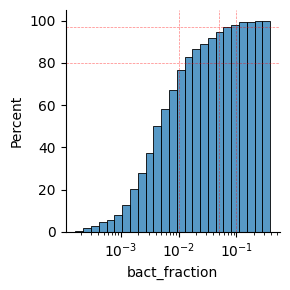

In [ ]:
g = sns.displot(
    data=bact_fraction, 
    x='bact_fraction',
    height=3.0, aspect=1.0,
    log_scale=(True, False),
    bins=25, cumulative=True, stat='percent'
)
g.ax.axvline(0.01, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axvline(0.05, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axvline(0.10, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axhline(97, linestyle='--', color='red', alpha=.5, linewidth=.5)
g.ax.axhline(80, linestyle='--', color='red', alpha=.5, linewidth=.5)
# g.savefig("figures/fig02.other-fraction.svg")

## Library length

In [ ]:
with open("raw/library-lengths/.input", "r") as f:
    fastp_files =  list(map(lambda x: x.strip(), f.readlines()))

In [ ]:
length_data = []
for file in fastp_files:
    with open(f"raw/library-lengths/{file}") as f:
        u = json.load(f)['summary']['before_filtering']
        u['library'] = file.replace(".fastp.json", "")
        length_data.append(u)
length_data = pd.DataFrame.from_records(length_data)
length_data

,total_reads,total_bases,q20_bases,q30_bases,q20_rate,q30_rate,read1_mean_length,read2_mean_length,gc_content,library
0,19719226,2977603126,2876651552,2712577270,0.966096,0.910994,151,151,0.426118,PV051
1,13967266,2109057166,2046158117,1947478380,0.970177,0.923388,151,151,0.424001,PV052
2,16259506,2455185406,2381404566,2267326363,0.969949,0.923485,151,151,0.422853,PV053
3,15370124,2320888724,2237090733,2113711384,0.963894,0.910734,151,151,0.457129,PV054
4,20152164,3042976764,2940100792,2790224904,0.966192,0.916939,151,151,0.415057,PV056
...,...,...,...,...,...,...,...,...,...,...
282,2598,392298,260362,214330,0.663684,0.546345,151,151,0.448317,PV95
283,31414886,4743647786,4551190942,4282662065,0.959429,0.902820,151,151,0.462473,PV96
284,58983802,8906554102,8571001510,8082779176,0.962325,0.907509,151,151,0.449425,PV97
285,29423102,4442888402,4278639568,4039958969,0.963031,0.909309,151,151,0.450941,PV98


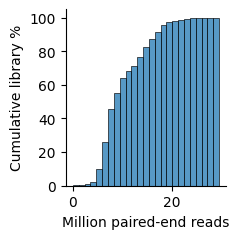

In [ ]:
length_data['total_reads_Mpreads'] = length_data['total_reads'] / 2e6
g = sns.displot(data=length_data, x='total_reads_Mpreads', bins=25, height=2.5, cumulative=True, stat='percent', log_scale=(False, False))
g.set_xlabels("Million paired-end reads")
g.set_ylabels("Cumulative library %")
g.savefig("figures/fig02.library-size.svg")